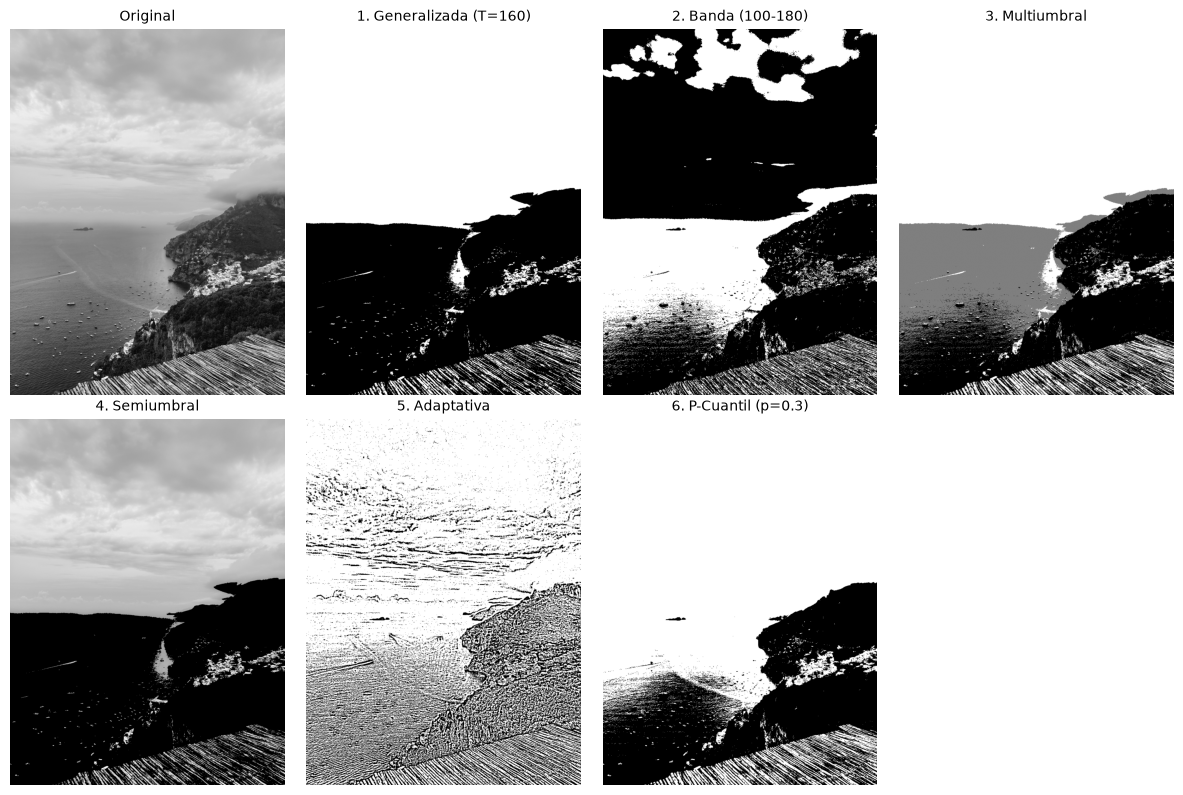

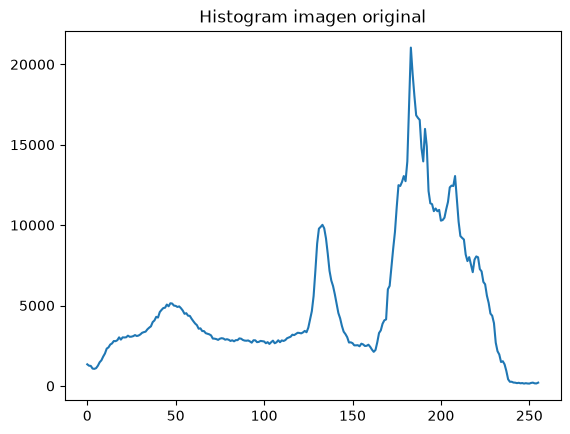

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# CARGA DE IMAGEN
# -------------------------------------------------------------------------
# Cargamos una imagen de ejemplo en escala de grises.
imagen_original = cv2.imread('Positano.jpg', cv2.IMREAD_GRAYSCALE)

if imagen_original is None:
    # Si no encuentra el archivo, generamos una imagen de degradado sintética
    print("Imagen no encontrada. Generando una imagen de degradado para pruebas...")
    imagen_original = np.tile(np.arange(256, dtype=np.uint8), (256, 1))

# -------------------------------------------------------------------------
# 1. UMBRALIZACIÓN GENERALIZADA (Simple / Binaria)
# -------------------------------------------------------------------------
# Píxeles por encima del umbral 'T' toman el valor máximo (255), de lo contrario 0.
T1 = 160
_, umbral_generalizada = cv2.threshold(imagen_original, T1, 255, cv2.THRESH_BINARY)

# -------------------------------------------------------------------------
# 2. UMBRALIZACIÓN DE BANDA (o Ventana)
# -------------------------------------------------------------------------
# Selecciona los píxeles que están estrictamente dentro de un rango [T_min, T_max].
T_min, T_max = 100, 180
umbral_banda = np.where((imagen_original >= T_min) & (imagen_original <= T_max), 255, 0).astype(np.uint8)

# -------------------------------------------------------------------------
# 3. MULTIUMBRALIZACIÓN (Múltiples niveles de gris)
# -------------------------------------------------------------------------
# Divide la imagen en múltiples rangos de intensidad asignándoles valores fijos.
T_mult1, T_mult2 = 100, 160
multiumbral = np.zeros_like(imagen_original)
multiumbral[imagen_original < T_mult1] = 0
multiumbral[(imagen_original >= T_mult1) & (imagen_original < T_mult2)] = 127
multiumbral[imagen_original >= T_mult2] = 255

# -------------------------------------------------------------------------
# 4. SEMIUMBRALIZACIÓN
# -------------------------------------------------------------------------
# Los píxeles sobre el umbral conservan su nivel original, los menores se van a 0.
T4 = 160
_, semiumbral = cv2.threshold(imagen_original, T4, 255, cv2.THRESH_TOZERO)

# -------------------------------------------------------------------------
# 5. UMBRALIZACIÓN ADAPTATIVA (Local)
# -------------------------------------------------------------------------
# El umbral se calcula píxel a píxel usando el promedio de su vecindario (bloque).
# Ideal para corregir problemas de iluminación no uniforme.
umbral_adaptativa = cv2.adaptiveThreshold(
    imagen_original, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
    cv2.THRESH_BINARY, 11, 2
)

# -------------------------------------------------------------------------
# 6. MÉTODO P-CUANTIL (Basado en el porcentaje de área del objeto)
# -------------------------------------------------------------------------
# Si sabemos que el objeto ocupa aproximadamente el 'p' por ciento de la imagen,
# calculamos el percentil estadístico correspondiente en el histograma.
p = 0.30  # Asumimos que el objeto de interés ocupa el 40% más oscuro de la imagen
T_cuantil = np.percentile(imagen_original, p * 100)
_, umbral_p_cuantil = cv2.threshold(imagen_original, T_cuantil, 255, cv2.THRESH_BINARY)

# -------------------------------------------------------------------------
# VISUALIZACIÓN DE RESULTADOS
# -------------------------------------------------------------------------
titulos = [
    'Original', '1. Generalizada (T=160)', f'2. Banda ({T_min}-{T_max})',
    '3. Multiumbral', '4. Semiumbral', '5. Adaptativa', f'6. P-Cuantil (p={p})'
]
imagenes = [
    imagen_original, umbral_generalizada, umbral_banda,
    multiumbral, semiumbral, umbral_adaptativa, umbral_p_cuantil
]

plt.figure(figsize=(12, 8))
for i in range(7):
    plt.subplot(2, 4, i + 1)
    plt.imshow(imagenes[i], cmap='gray')
    plt.title(titulos[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Histogram
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

hist = cv2.calcHist([imagen_original], [0], None, [256], [0, 256])
plt.plot(hist)
plt.title("Histogram imagen original")
plt.show()


## Explicación rápida de las implementaciones:

• Generalizada y Semiumbral: Se resuelven de forma nativa y eficiente con la función cv2.threshold, usando los modos THRESH_BINARY y THRESH_TOZERO respectivamente.
• De Banda y Multiumbral: Requieren una lógica de rangos condicionales. Se optimizan usando máscaras booleanas directas de numpy (np.where).
• Adaptativa: OpenCV proporciona cv2.adaptiveThreshold, que calcula dinámicamente el umbral en un bloque cercano (en este caso de 11x11 píxeles) para mitigar sombras.
• Método p-cuantil: Aprovecha la función np.percentile para encontrar exactamente el valor de gris que divide la imagen bajo la proporción estadística ingresada (\(p\)).


### Localización de mínimos en el histograma mediante derivadas

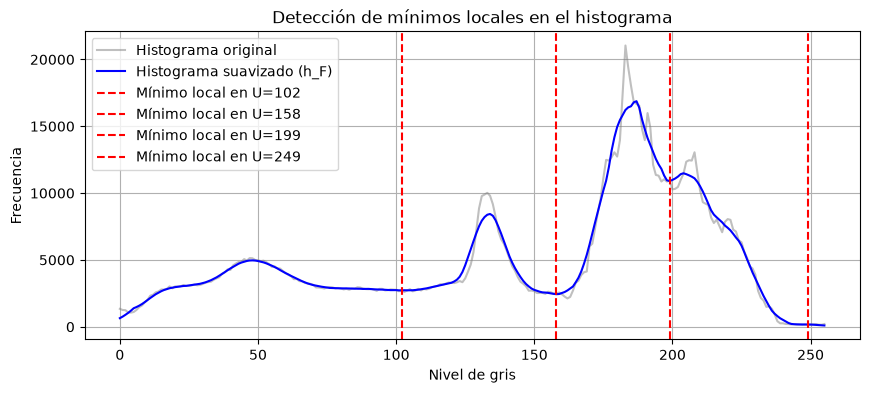

Umbrales detectados en valles del histograma: [102 158 199 249]


In [4]:
# Algoritmo de localización de mínimos locales en el histograma:
# Paso 1: Cálculo del histograma y filtrado paso bajo (promedio móvil)
# h = cv2.calcHist([img_sint], [0], None, [256], [0, 256]).flatten()
from scipy.signal import find_peaks
V = 11  # Tamaño ventana del filtro paso bajo
filtro = np.ones(V) / V
h_filtrado = np.convolve(hist, filtro, mode='same')

# Paso 2: Derivadas discretas del histograma
dh = np.diff(h_filtrado)
d2h = np.diff(dh)

# Paso 3: Identificar valles (dh cerca de 0 y concavidad positiva d2h > 0)
valles, _ = find_peaks(-h_filtrado, distance=30)

plt.figure(figsize=(10, 4))
plt.plot(hist, label='Histograma original', color='gray', alpha=0.5)
plt.plot(h_filtrado, label='Histograma suavizado (h_F)', color='blue')
for v in valles:
    plt.axvline(v, color='red', linestyle='--', label=f'Mínimo local en U={v}')
plt.title("Detección de mínimos locales en el histograma")
plt.xlabel("Nivel de gris")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

print(f"Umbrales detectados en valles del histograma: {valles}")

### Comparativa Multiumbralización Global vs. Umbralización Adaptativa

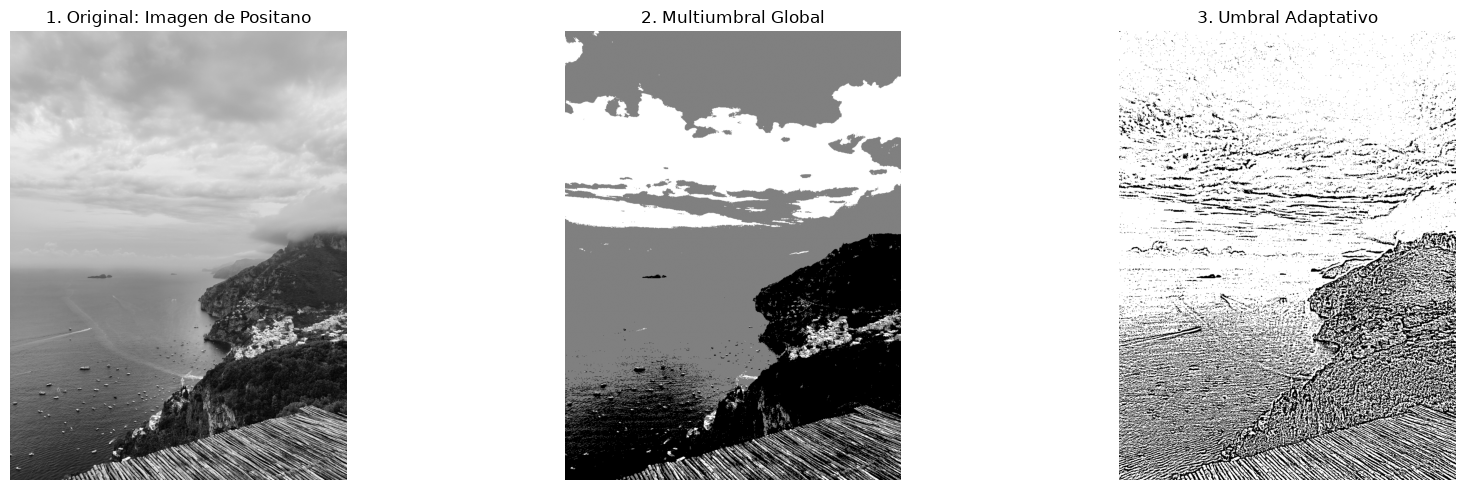

In [7]:
# 1. Multiumbralización Global (Intentar separar por niveles fijos de gris)

# Definimos 3 rangos fijos para toda la imagen:
# - Fondo muy claro: > 200
# - Intensidad media: entre 100 y 200
# - Oscuro: < 100
multi_global = np.zeros_like(imagen_original)
multi_global[(imagen_original >= 100) & (imagen_original < 200)] = 128  # Nivel intermedio (Gris)
multi_global[imagen_original >= 200] = 255                       # Nivel alto (Blanco)
# Lo menor a 100 se queda en 0 (Negro)



# -------------------------------------------------------------------------
# 2. UMBRALIZACIÓN ADAPTATIVA (Local)
# -------------------------------------------------------------------------
# El umbral se calcula píxel a píxel usando el promedio de su vecindario (bloque).
# Ideal para corregir problemas de iluminación no uniforme.
umbral_adaptativa = cv2.adaptiveThreshold(
    imagen_original, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
    cv2.THRESH_BINARY, 11, 2
)

# 3. Mostrar el resultado

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(imagen_original, cmap='gray')
axes[0].set_title("1. Original: Imagen de Positano", fontsize=12)
axes[0].axis('off')

axes[1].imshow(multi_global, cmap='gray')
axes[1].set_title("2. Multiumbral Global", fontsize=12)
axes[1].axis('off')

axes[2].imshow(umbral_adaptativa, cmap='gray')
axes[2].set_title("3. Umbral Adaptativo", fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()


### Otsu vs. Umbralización Adaptativa con iluminación no homogénea

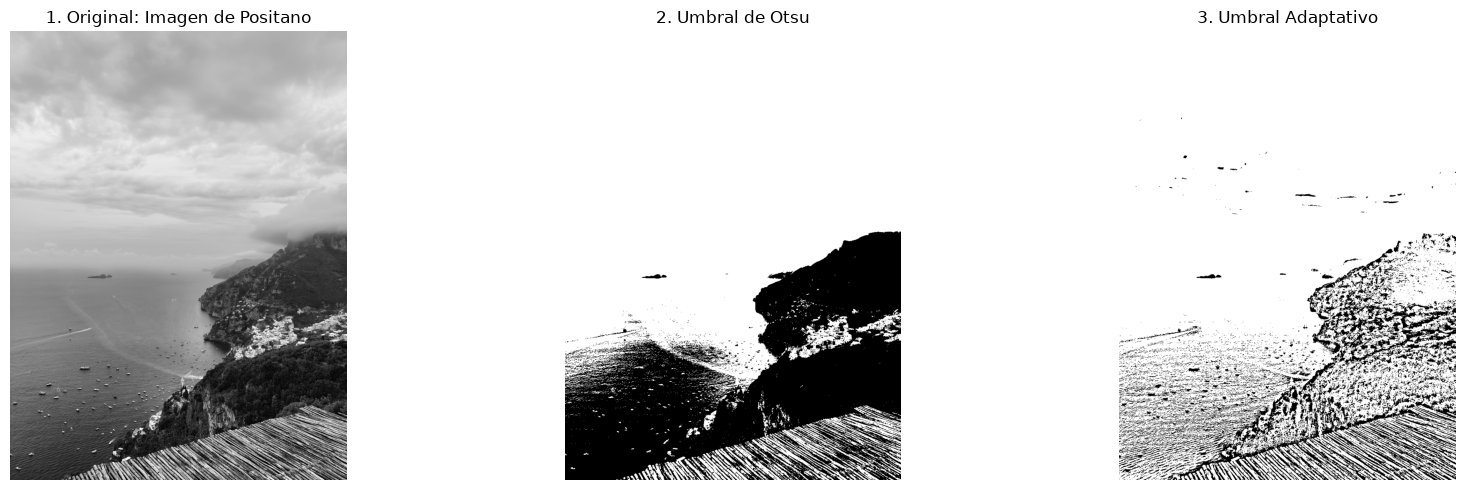

In [9]:
# 1. Umbralización Global de Otsu
_, bin_otsu = cv2.threshold(imagen_original, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 2. Umbralización Adaptativa (Media local en vecindad de 25x25)
bin_adapt_mean = cv2.adaptiveThreshold(
    imagen_original, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 25, 10
)

# 4. Mostrar el resultado

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(imagen_original, cmap='gray')
axes[0].set_title("1. Original: Imagen de Positano", fontsize=12)
axes[0].axis('off')

axes[1].imshow(bin_otsu, cmap='gray')
axes[1].set_title("2. Umbral de Otsu", fontsize=12)
axes[1].axis('off')

axes[2].imshow(bin_adapt_mean, cmap='gray')
axes[2].set_title("3. Umbral Adaptativo", fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Selección del umbral con Gradiente y Laplaciano

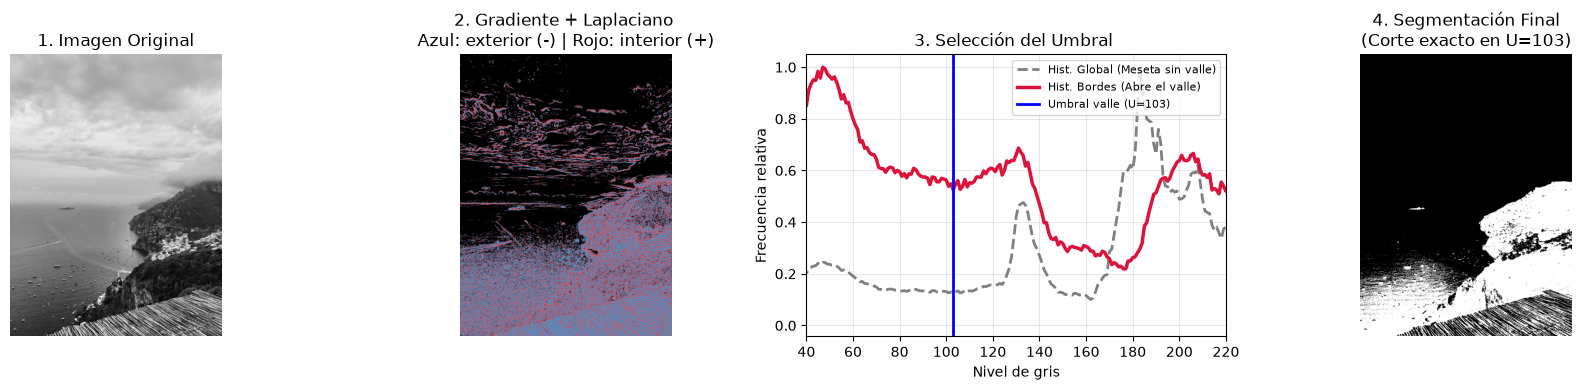

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Detectar dimensiones de la imagen original
h, w = imagen_original.shape
mapa_visual = np.zeros((h, w, 3), dtype=np.uint8)

# 1. GRADIENTE Y LAPLACIANO 

img_suave = cv2.GaussianBlur(imagen_original, (3, 3), 0)

# Gradiente espacial (magnitud del salto local) - kernel 3X3
gx = cv2.Sobel(img_suave, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(img_suave, cv2.CV_32F, 0, 1, ksize=3)
grad = cv2.magnitude(gx, gy)

# Laplaciano: clasifica el lado del contorno (cruce por cero en la frontera)
# El laplaciano responde a cambios rápidos de brillo, por lo que puede ayudar a localizar bordes y distinguir los dos lados de una transición por el signo de sus valores.
lap = cv2.Laplacian(img_suave, cv2.CV_32F, ksize=3)

# Clasificación estricta en el contorno (|grad| >= T):
# Estas líneas crean máscaras que seleccionan bordes fuertes y los dividen según el signo de Laplace:
T_grad = 10.0
borde_mask = grad >= T_grad
lado_oscuro = borde_mask & (lap >= 0)  # Signo '+' (lado interior oscuro)
lado_claro  = borde_mask & (lap < 0)   # Signo '-' (lado exterior claro)


# 2. HISTOGRAMAS COMPARADOS (Normalizados para ver la forma de la curva)
# Ambas líneas calculan histogramas de 256 bins de valores de píxeles en escala de grises y transforman los resultados en matrices unidimensionales.

# The arguments specify: input image, channel 0, no mask (None), 256 bins, and intensity range 0–255.
h_global = cv2.calcHist([imagen_original], [0], None, [256], [0, 256]).flatten()

# Primero, selecciona solo los valores de píxeles donde borde_mask es verdadero y luego cuenta esos valores. Por lo tanto, 
# describe la distribución de intensidad en los bordes detectados, en lugar de en toda la imagen.
h_bordes = cv2.calcHist([imagen_original[borde_mask]], [0], None, [256], [0, 256]).flatten()

# Normalizamos a [0, 1] para que ambas curvas se aprecien con claridad
h_global_norm = h_global / np.max(h_global)
h_bordes_norm = h_bordes / np.max(h_bordes)

# Suavizado de la curva de bordes para detectar el mínimo (valle)
# Estas líneas suavizan el histograma de los bordes y buscan el nivel de gris con menor frecuencia 
# entre 60 y 120:
# reshape(-1, 1) convierte el histograma en una columna para que OpenCV pueda aplicar el filtro.
# GaussianBlur(..., (9, 1), 0) suaviza los valores de cada bin usando una ventana de 9 posiciones
# flatten() vuelve a convertir el resultado en un arreglo unidimensional.
h_bordes_smooth = cv2.GaussianBlur(h_bordes_norm.reshape(-1, 1), (9, 1), 0).flatten()
rango_busqueda = np.arange(60, 120)
# Busca cuál de esos niveles tiene la frecuencia suavizada más baja y asigna ese nivel a umbral_optimo. 
# Así, el umbral queda limitado al rango elegido; 
# si el valle real está fuera de 60–120, este código no lo detectará.
umbral_optimo = rango_busqueda[np.argmin(h_bordes_smooth[rango_busqueda])]

# Segmentación binaria con el umbral hallado
# Si el píxel es mayor que el umbral, lo convierte en 0 (negro).
# Si es menor o igual, lo convierte en 255 (blanco).
_, bin_resultado = cv2.threshold(imagen_original, umbral_optimo, 255, cv2.THRESH_BINARY_INV)


# 3. VISUALIZACIÓN

fig, axs = plt.subplots(1, 4, figsize=(18, 4))

# Panel 1: Original con solapamiento
axs[0].imshow(imagen_original, cmap='gray')
axs[0].set_title("1. Imagen Original")
axs[0].axis('off')

# Panel 2: Mapa de contorno con Laplaciano
mapa_visual = np.zeros((h, w, 3), dtype=np.uint8)
mapa_visual[lado_claro]  = [0, 180, 255] # Azul: Lado claro exterior (-)
mapa_visual[lado_oscuro] = [255, 60, 60] # Rojo: Lado oscuro interior (+)
axs[1].imshow(mapa_visual)
axs[1].set_title("2. Gradiente + Laplaciano \nAzul: exterior (-) | Rojo: interior (+)")
axs[1].axis('off')

# Panel 3: Comparativa de Histogramas 
axs[2].plot(h_global_norm, color='gray', linestyle='--', lw=2, label='Hist. Global (Meseta sin valle)')
axs[2].plot(h_bordes_smooth, color='crimson', lw=2.5, label='Hist. Bordes (Abre el valle)')
axs[2].axvline(umbral_optimo, color='blue', lw=2, linestyle='-', label=f'Umbral valle (U={umbral_optimo})')
axs[2].set_xlim(40, 220)
axs[2].set_title("3. Selección del Umbral ")
axs[2].set_xlabel("Nivel de gris")
axs[2].set_ylabel("Frecuencia relativa")
axs[2].legend(fontsize=8, loc='upper right')
axs[2].grid(True, alpha=0.3)

# Panel 4: Binarización limpia
axs[3].imshow(bin_resultado, cmap='gray')
axs[3].set_title(f"4. Segmentación Final\n(Corte exacto en U={umbral_optimo})")
axs[3].axis('off')

plt.tight_layout()
plt.show()